In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.datasets import load_iris
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score ,classification_report 



In [2]:
df=pd.read_csv('AQI.csv')

In [3]:
df.duplicated().sum()

np.int64(0)

In [4]:
df['PM2.5']=df['PM2.5'].fillna(df['PM2.5'].median())

In [5]:
df['PM10']=df['PM10'].fillna(df['PM10'].median())

In [6]:
df['NO']=df['NO'].fillna(df['NO'].median())

In [7]:

df['NO2']=df['NO2'].fillna(df['NO2'].median())

In [8]:
df['NOx']=df['NOx'].fillna(df['NOx'].median())

In [9]:

df['NH3']=df['NH3'].fillna(df['NH3'].median())

In [10]:
df['CO']=df['CO'].fillna(df['CO'].median())

In [11]:
df['SO2']=df['SO2'].fillna(df['SO2'].median())

In [12]:
df['O3']=df['O3'].fillna(df['O3'].median())

In [13]:
df['Benzene']=df['Benzene'].fillna(df['Benzene'].median())

In [14]:
df['Toluene']=df['Toluene'].fillna(df['Toluene'].median())

In [15]:
df['Xylene']=df['Xylene'].fillna(df['Xylene'].median())

In [16]:
df.describe(include='all')

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
count,29531,29531,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,24850.000000,24850
unique,26,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
top,Ahmedabad,2020-06-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Moderate
freq,2009,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8829
mean,NaN,NaN,64.510857,109.659366,16.642601,27.726576,31.063568,20.813789,2.153872,13.830897,33.994121,2.859874,7.140485,1.788420,166.463581,NaN
std,NaN,NaN,59.807551,72.324020,21.506064,23.050531,29.477748,21.028862,6.724660,17.005647,20.202304,14.252822,17.224737,4.062039,140.696585,NaN
min,NaN,NaN,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000,NaN
25%,NaN,NaN,32.150000,79.315000,6.210000,12.980000,14.670000,12.040000,0.540000,6.090000,20.740000,0.240000,1.280000,0.980000,81.000000,NaN
50%,NaN,NaN,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000,NaN
75%,NaN,NaN,72.450000,111.880000,17.570000,34.665000,36.015000,21.755000,1.380000,13.810000,42.730000,2.420000,6.020000,0.980000,208.000000,NaN


In [17]:
df.isnull().sum()

City             0
Date             0
PM2.5            0
PM10             0
NO               0
NO2              0
NOx              0
NH3              0
CO               0
SO2              0
O3               0
Benzene          0
Toluene          0
Xylene           0
AQI           4681
AQI_Bucket    4681
dtype: int64

In [18]:
df['AQI']=df['AQI'].fillna(df['AQI'].median())

In [19]:
df['AQI_Bucket']=df['AQI_Bucket'].fillna(df['AQI_Bucket'].mode()[0])

In [20]:
df.isnull().sum()

City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
Xylene        0
AQI           0
AQI_Bucket    0
dtype: int64

In [21]:
x=df.drop(['AQI'],axis=1)

In [22]:
y=df['AQI']

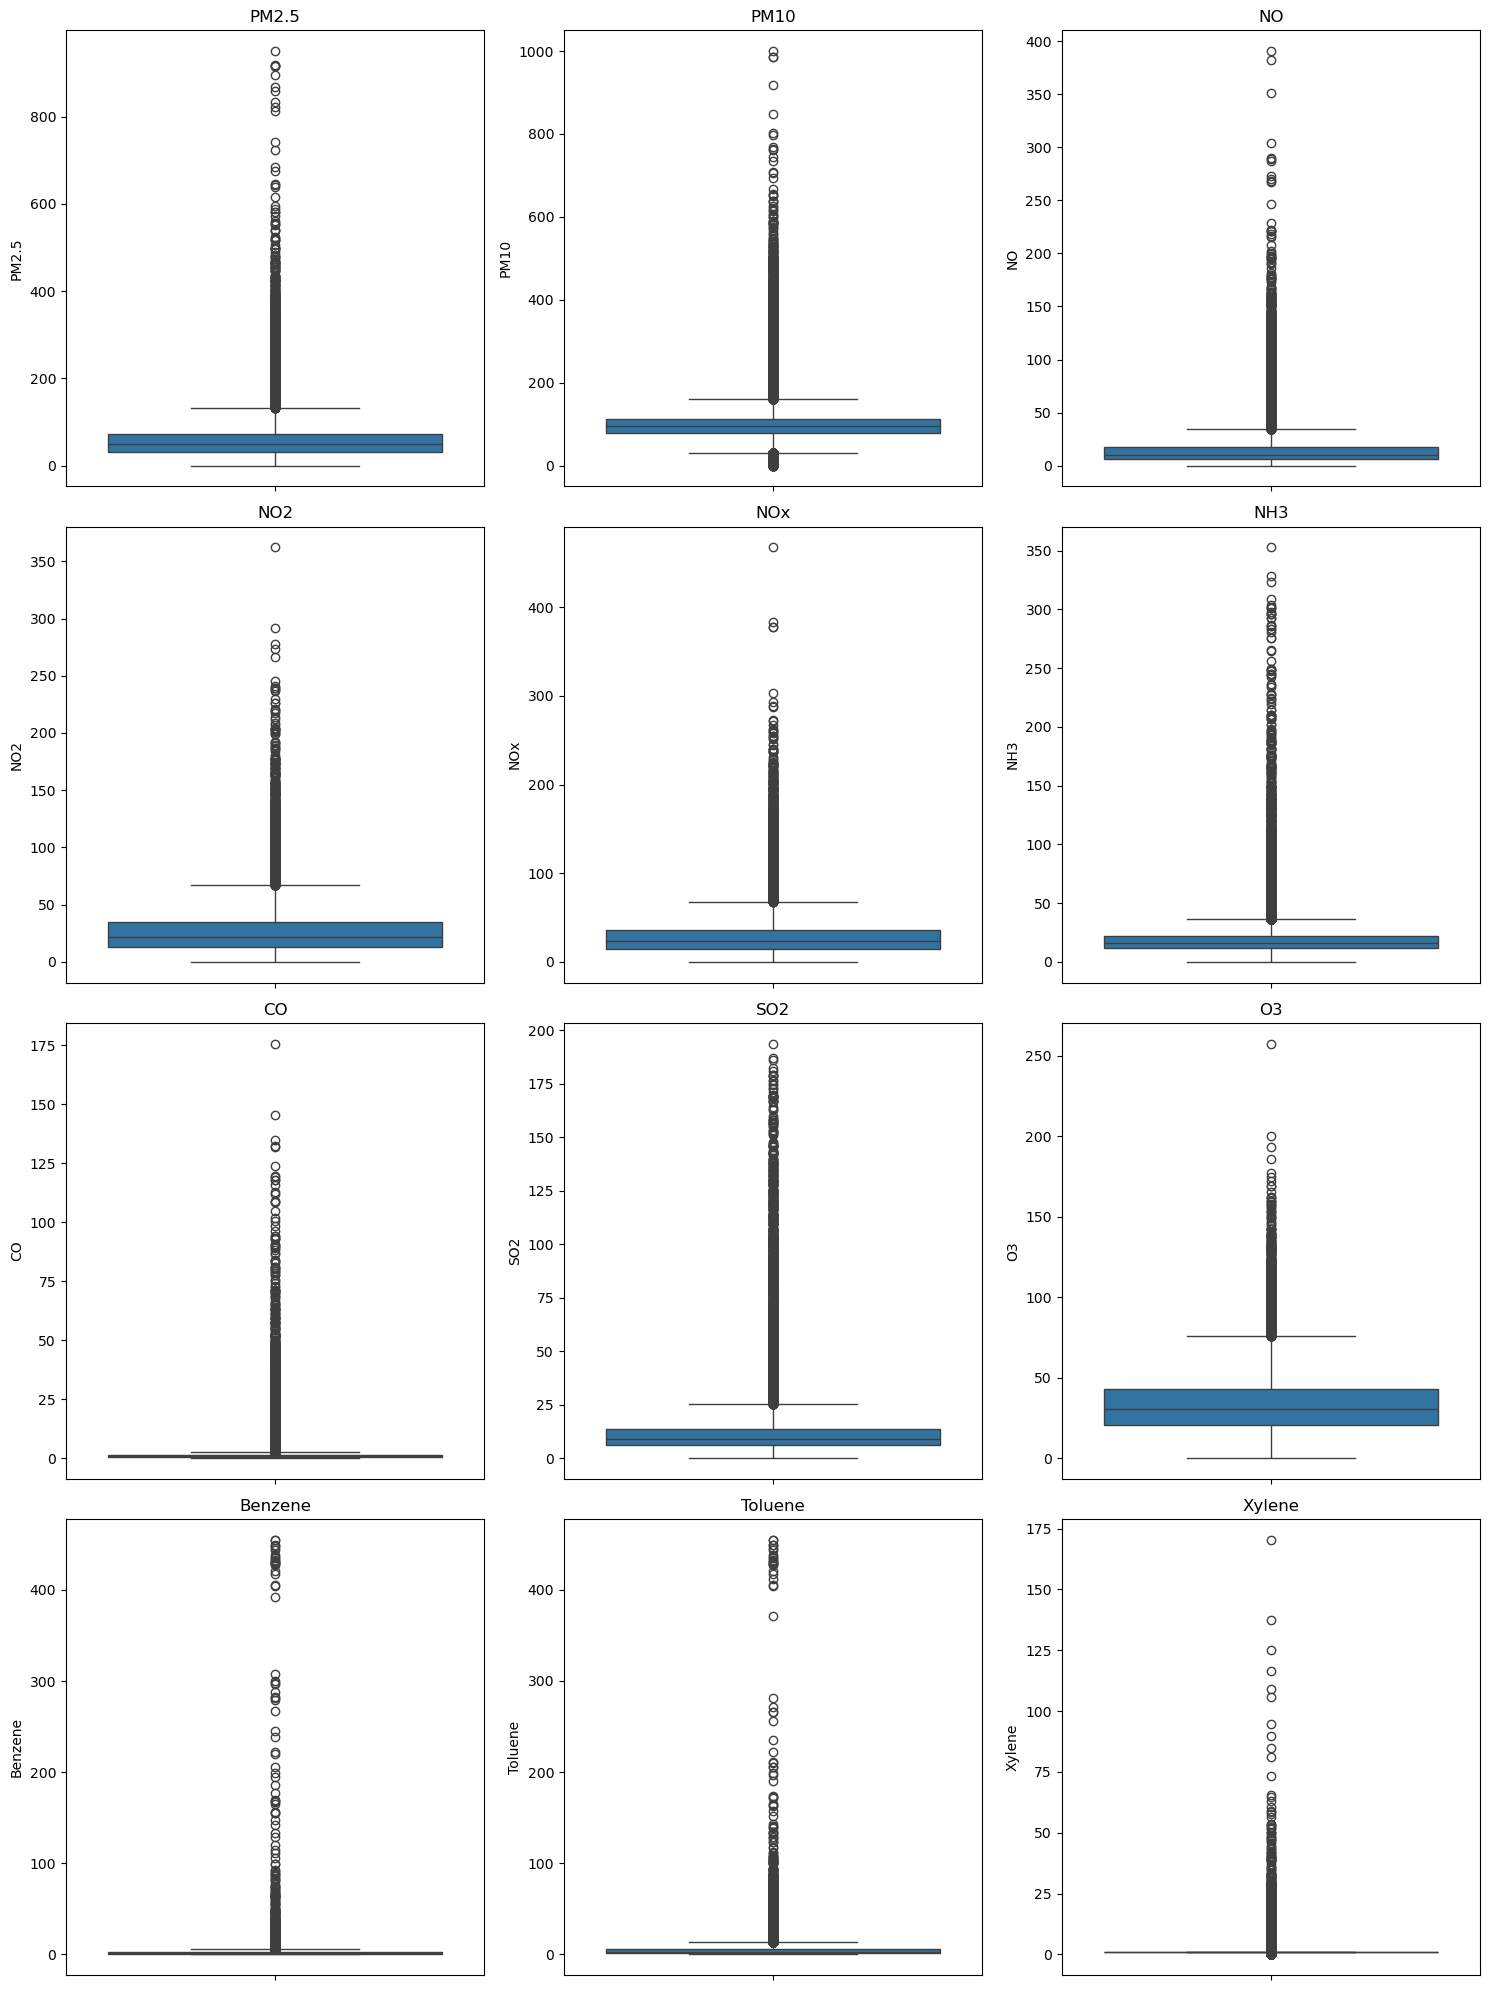

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

num_cols = x.select_dtypes(include='number').columns

n_cols = 3   # number of columns in subplot
n_rows = math.ceil(len(num_cols) / n_cols)

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(num_cols):
    plt.subplot(n_rows, n_cols, i + 1)

    sns.boxplot(y=x[col])

    plt.title(col)

plt.tight_layout()
plt.show()

In [24]:
num_cols = x.select_dtypes(include=['int64', 'float64']).columns

def cap_outliers(x, cols):
    x = x.copy()
    
    for col in cols:
        Q1 = x[col].quantile(0.25)
        Q3 = x[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        x[col] = x[col].clip(lower, upper)
    
    return x

x = cap_outliers(x, num_cols)

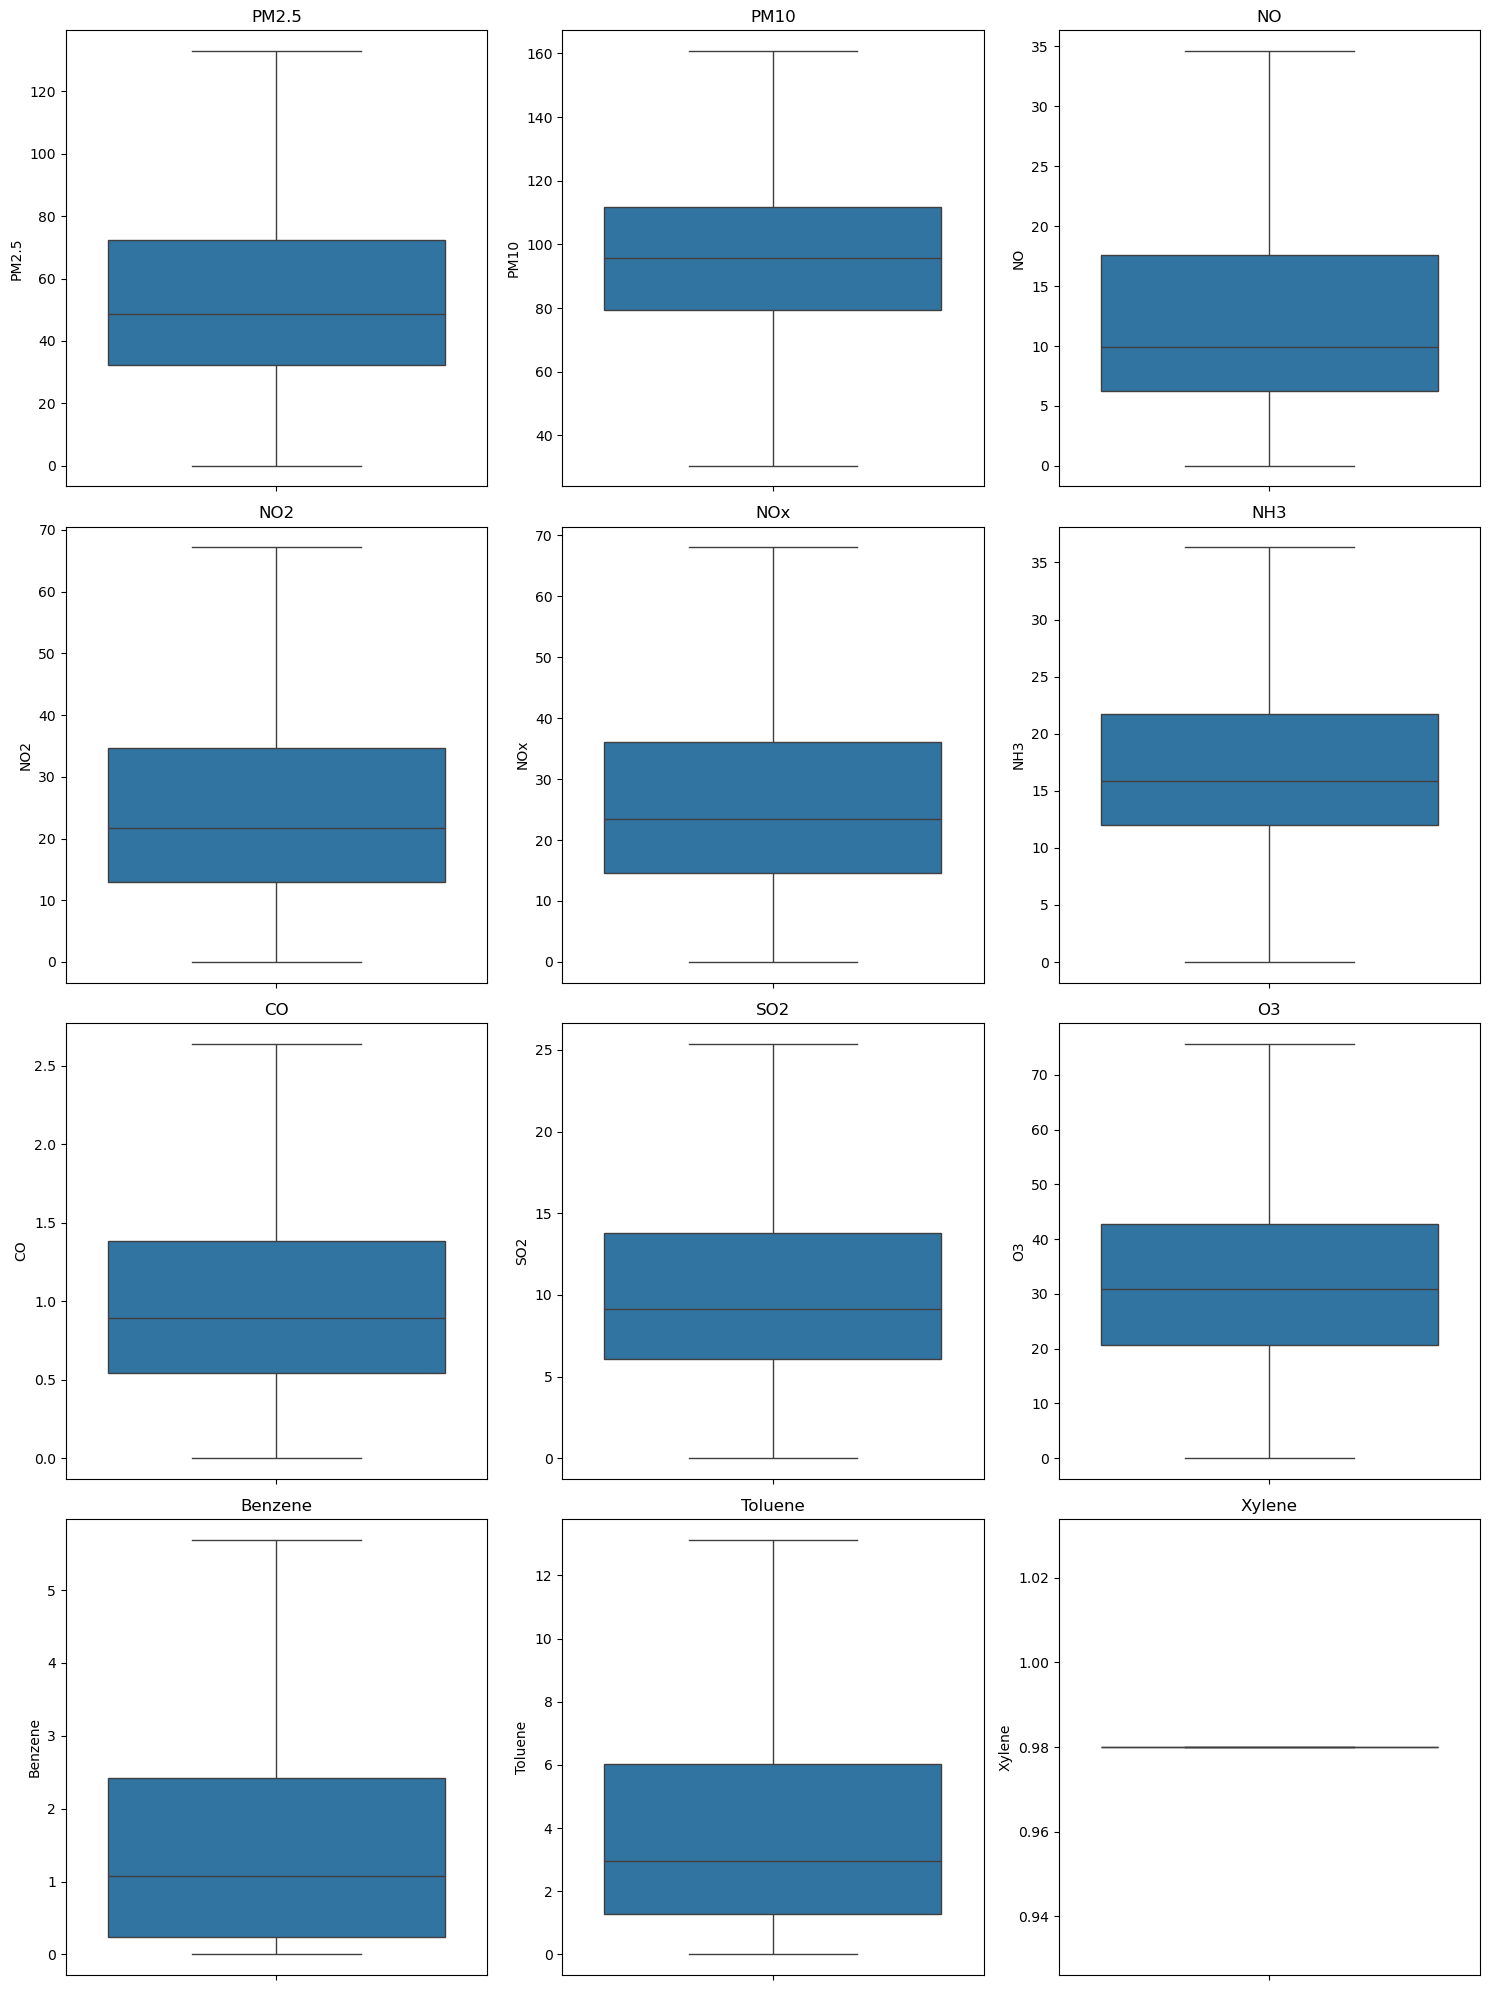

In [25]:
num_cols = x.select_dtypes(include='number').columns

n_cols = 3   # number of columns in subplot
n_rows = math.ceil(len(num_cols) / n_cols)

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(num_cols):
    plt.subplot(n_rows, n_cols, i + 1)

    sns.boxplot(y=x[col])

    plt.title(col)

plt.tight_layout()
plt.show()

In [26]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

In [27]:
cat_cols=x.select_dtypes(include='object').columns
cat_cols

Index(['City', 'Date', 'AQI_Bucket'], dtype='object')

In [28]:
num_cols=x.select_dtypes(include='number').columns
num_cols

Index(['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3',
       'Benzene', 'Toluene', 'Xylene'],
      dtype='object')

In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder,StandardScaler
ct = ColumnTransformer(transformers=[
    ("oe", OrdinalEncoder(), cat_cols),
    ("sc", StandardScaler(), num_cols)
], remainder='passthrough')

In [30]:
x_transformed=ct.fit_transform(x)

In [31]:
# train test split
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x_transformed, y, test_size=0.2, random_state=42
)

# import Linear Regression
from sklearn.linear_model import LinearRegression

# create model
lr = LinearRegression()

# train model
lr.fit(x_train, y_train)

# predictions
y_pred = lr.predict(x_test)

print(y_pred)

[ 71.0410034   72.69990102 109.51440594 ...  84.64489849  81.35720611
  95.67110371]


In [32]:
from sklearn.metrics import r2_score
print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.6692554207652803


In [33]:
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

In [44]:
ls=Lasso(alpha=0.5)
ls.fit(x_train,y_train)
ls.predict(x_test)


array([ 71.59570259,  73.2319867 , 109.77459421, ...,  89.091573  ,
        81.68824961,  98.62958584])

In [45]:
r2=r2_score(y_test,y_pred)
r2

0.6692554207652803

In [46]:
red=Ridge()
red.fit(x_train,y_train)
red.predict(x_train)

array([431.84756349, 132.01777618, -17.14067128, ..., 144.23820356,
        80.7156451 , 110.71193543])

In [47]:
r2=r2_score(y_test,y_pred)
r2

0.6692554207652803